In [12]:
# Imports, as always...
from pathlib import Path
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split as tts
from scripts.data import QuantumDataset, stratified_sample

import torch
import torch.nn as nn

import warnings
warnings.filterwarnings('ignore')

seed = 42
torch.random.manual_seed(seed)

test_split, val_split = .2, .2

device = 'cuda' if torch.cuda.is_available() else 'cpu'

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import cmcrameri.cm as cmc
palette = 'deep'
sns.set_theme(style='darkgrid', palette=palette)

In [23]:
# Device colours, for consistency.
colours = cmc.berlin([0, .3, 1])

In [102]:
# Raw data.
raw_data = pd.concat([
    pd.read_csv(data_csv) 
    for data_csv in Path('./data/depth-varied').glob('*.csv')
], ignore_index=True)

## Extracting Penultimate Layer Logits as Vectorised Representations: *Differing*-Type Devices

In [103]:
# Differing-type device.
model = nn.Sequential(
    nn.Linear(32, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(.5),
    nn.Linear(64, 16), nn.BatchNorm1d(16), nn.ReLU(), nn.Dropout(.5),
    nn.Linear(16, 2)
)
model.to(device)
model.load_state_dict(torch.load('./models/diff_type_raw_10.pt'))
model.eval()

Sequential(
  (0): Linear(in_features=32, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=64, out_features=16, bias=True)
  (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.5, inplace=False)
  (8): Linear(in_features=16, out_features=2, bias=True)
)

In [104]:
# Subset for between devices of the same type:
subset_same = raw_data[raw_data['device'] != 'Aria-1'].replace({'Ankaa-3':0, 'Garnet':1})
# Subset for between devices of differing type:
subset_diff = raw_data[raw_data['device'] != 'Garnet'].replace({'Ankaa-3':0, 'Aria-1':1})

dataset = QuantumDataset(stratified_sample(subset_diff[subset_diff['d'] == 10], n=350), 'raw')
train_set, test_set = tts(dataset, test_size=test_split, shuffle=True, random_state=seed)
train_set, val_set = tts(train_set, test_size=val_split, shuffle=True, random_state=seed)

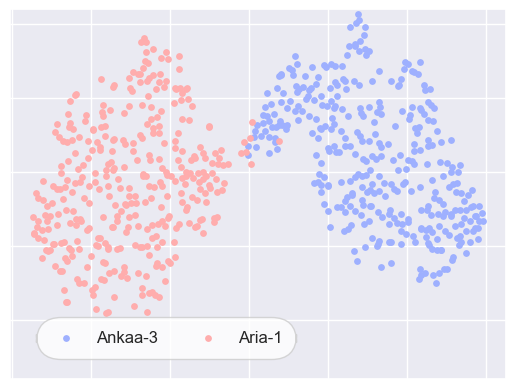

In [105]:
# Hook on the penultimate layer.
hook = model[4].register_forward_hook(lambda module, input, output: penultimate_outputs.append(output.detach().cpu()))
penultimate_outputs = []

# Inference over the entire dataset.
features = []
labels = []
with torch.no_grad():
    for i in range(len(dataset)):
        x, y = dataset[i]
        x = x.unsqueeze(0)
        x = x.to(device)

        # Inference.
        penultimate_outputs.clear()
        _ = model(x)

        # Extract penultimate logits and label.
        feat = penultimate_outputs[0].squeeze(0).numpy()
        features.append(feat)
        labels.append(int(y))

hook.remove()

features = np.array(features)
labels = np.array(labels)

# Dim-reduction on features.
tsne = TSNE(n_components=2, random_state=seed)
features_2d = tsne.fit_transform(features)

# Split by label for hue-ing.
feats_0 = features[labels == 0]
feats_1 = features[labels == 1]

# Plot
plt.figure()
marker_size = 15
plt.scatter(
    features_2d[labels == 0, 0], 
    features_2d[labels == 0, 1], 
    s=marker_size,
    color=colours[0],
    label='Ankaa-3'
)
plt.scatter(
    features_2d[labels == 1, 0], 
    features_2d[labels == 1, 1], 
    s=marker_size,
    color=colours[2],
    label='Aria-1'
)

# Manual legend.
leg = plt.legend(
    loc='lower left', 
    bbox_to_anchor=(.05, .05),
    fontsize=12,
    frameon=True, 
    fancybox=True,    
    framealpha=.8,       
    facecolor='white', 
    ncol=2,
)
frame = leg.get_frame()
frame.set_boxstyle('round', pad=0.4, rounding_size=1.5)  

# Remove tick markers, but keep the grid.
plt.tick_params(axis='both', which='both', labelbottom=False, labelleft=False)
plt.ylim(-14, 11)

plt.show()


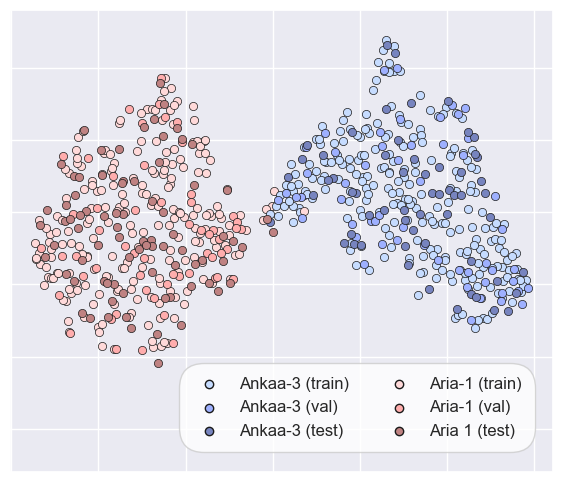

In [107]:
# Helper function to let us adjust the colours for plotting.
def adjust_brightness(color, factor):
    rgb = np.array(mcolors.to_rgb(color))
    rgb = np.clip(rgb * factor, 0, 1)
    return rgb

# Hook on the penultimate layer.
hook = model[4].register_forward_hook(lambda module, input, output: penultimate_outputs.append(output.detach().cpu()))
penultimate_outputs = []

def extract_features(dataset):
    # Inference over the entire dataset.
    features = []
    labels = []
    with torch.no_grad():
        for i in range(len(dataset)):
            x, y = dataset[i]
            x = x.unsqueeze(0)
            x = x.to(device)
    
            # Inference.
            penultimate_outputs.clear()
            _ = model(x)
    
            # Extract penultimate logits and label.
            feat = penultimate_outputs[0].squeeze(0).numpy()
            features.append(feat)
            labels.append(int(y))
            
    return np.array(features), np.array(labels)

# Extract features for each dataset.
train_feats, train_labels = extract_features(train_set)
val_feats, val_labels = extract_features(val_set)
test_feats, test_labels = extract_features(test_set)

hook.remove()

# Split by label.
train_0, train_1 = train_feats[train_labels == 0], train_feats[train_labels == 1]
val_0, val_1     = val_feats[val_labels == 0],     val_feats[val_labels == 1]
test_0, test_1   = test_feats[test_labels == 0],   test_feats[test_labels == 1]

# Combine all for fitting.
all_features = np.vstack([train_feats, val_feats, test_feats])
all_labels = np.concatenate([train_labels, val_labels, test_labels])
all_sets = np.concatenate([
    np.full(len(train_feats), "train"),
    np.full(len(val_feats), "val"),
    np.full(len(test_feats), "test")
])

# Dimensionality reduction.
tsne = TSNE(n_components=2, random_state=seed)
all_2d = tsne.fit_transform(all_features)

# Brightness factors per dataset.
brightness = {'train': 1.25, 'val': 1., 'test': .75}

# Plot
plt.figure(figsize=(7, 6))
idx = 0
for i in range(len(all_2d)):
    label = all_labels[i]
    subset = all_sets[i]

    base_color = colours[0] if label == 0 else colours[2]
    color = adjust_brightness(base_color, brightness[subset])

    plt.scatter(all_2d[i, 0], all_2d[i, 1], color=color, s=35, edgecolors='k', linewidths=.5)

# Legend (manual).
plt.scatter([], [], color=adjust_brightness(colours[0], brightness['train']), edgecolors='k', label='Ankaa-3 (train)')
plt.scatter([], [], color=adjust_brightness(colours[0], brightness['val']), edgecolors='k', label='Ankaa-3 (val)')
plt.scatter([], [], color=adjust_brightness(colours[0], brightness['test']), edgecolors='k', label='Ankaa-3 (test)')

plt.scatter([], [], color=adjust_brightness(colours[2], brightness['train']), edgecolors='k', label='Aria-1 (train)')
plt.scatter([], [], color=adjust_brightness(colours[2], brightness['val']), edgecolors='k', label='Aria-1 (val)')
plt.scatter([], [], color=adjust_brightness(colours[2], brightness['test']), edgecolors='k', label='Aria 1 (test)')

leg = plt.legend(
    loc='lower right', 
    bbox_to_anchor=(.97, .04),
    fontsize=12,
    frameon=True, 
    fancybox=True,    
    framealpha=.8,       
    facecolor='white', 
    ncol=2,
)
frame = leg.get_frame()
frame.set_boxstyle('round', pad=0.4, rounding_size=1.5)  

# Remove tick markers, but keep the grid.
plt.tick_params(axis='both', which='both', labelbottom=False, labelleft=False)
plt.ylim(-18, 14)

plt.savefig('./figures/fingerprint_visualisation/differ_type_raw_10.pdf', bbox_inches='tight')

plt.show()


## Extracting Penultimate Layer Logits as Vectorised Representations: *Like*-Type Devices

In [86]:
# Differing-type device.
model = nn.Sequential(
    nn.Linear(32, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(.5),
    nn.Linear(64, 16), nn.BatchNorm1d(16), nn.ReLU(), nn.Dropout(.5),
    nn.Linear(16, 3)
)
model.to(device)
model.load_state_dict(torch.load('./models/all_devices_raw_5.pt'))
model.eval()

Sequential(
  (0): Linear(in_features=32, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=64, out_features=16, bias=True)
  (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.5, inplace=False)
  (8): Linear(in_features=16, out_features=3, bias=True)
)

In [90]:
df_0 = raw_data[(raw_data['d'] == 5) & (raw_data['device'] == 'Ankaa-3')][:350]
df_1 = raw_data[(raw_data['d'] == 5) & (raw_data['device'] == 'Garnet')][:350]
df_2 = raw_data[(raw_data['d'] == 5) & (raw_data['device'] == 'Aria-1')]#[:350]

all_devices_df = pd.concat([df_0, df_1, df_2], ignore_index=True).replace({'Ankaa-3' : 0, 'Garnet' : 1, 'Aria-1' : 2})
all_dataset = QuantumDataset(all_devices_df, 'raw')
train_set, test_set = tts(all_dataset, test_size=test_split, shuffle=True, random_state=seed)
train_set, val_set = tts(train_set, test_size=val_split, shuffle=True, random_state=seed)

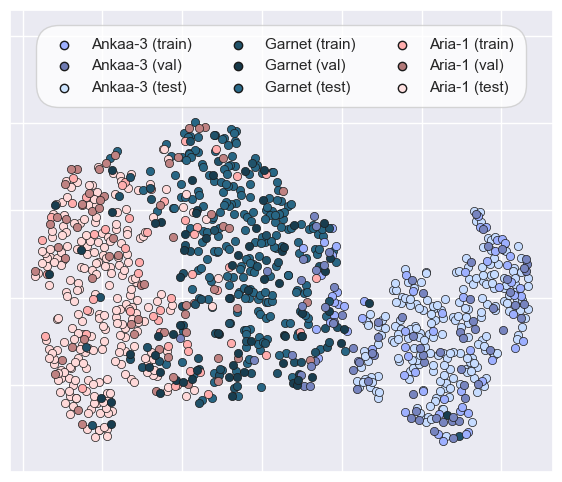

In [101]:
# Hook on the penultimate layer.
hook = model[4].register_forward_hook(lambda module, input, output: penultimate_outputs.append(output.detach().cpu()))
penultimate_outputs = []

# Extract features.
train_feats, train_labels = extract_features(train_set)
val_feats,   val_labels   = extract_features(val_set)
test_feats,  test_labels  = extract_features(test_set)

hook.remove()

# Combine all for fitting.
all_feats = np.vstack([train_feats, val_feats, test_feats])
all_labels = np.concatenate([train_labels, val_labels, test_labels])
all_sets = np.concatenate([
    np.full(len(train_feats), "train"),
    np.full(len(val_feats), "val"),
    np.full(len(test_feats), "test")
])

# Dimensionality reduction.
tsne = TSNE(n_components=2, random_state=seed)
all_2d = tsne.fit_transform(all_feats)

# Brightness per dataset
brightness = {"train": 1.25, "val": 1., "test": .75}

# Plot
plt.figure(figsize=(7, 6))

for i in range(len(all_2d)):
    label = all_labels[i]
    subset = all_sets[i]

    base_color = colours[label]
    color = adjust_brightness(base_color, brightness[subset])

    plt.scatter(all_2d[i, 0], all_2d[i, 1], color=color, s=35, edgecolors='k', linewidths=.5)

# Legend.
devices = {0 : 'Ankaa-3', 2 : 'Aria-1', 1 : 'Garnet'}
for cls_idx in range(3):
    base = colours[cls_idx]
    plt.scatter([], [], color=adjust_brightness(base, 1.0), edgecolors='k', label=f'{devices[cls_idx]} (train)')
    plt.scatter([], [], color=adjust_brightness(base, 0.7), edgecolors='k', label=f'{devices[cls_idx]} (val)')
    plt.scatter([], [], color=adjust_brightness(base, 1.3), edgecolors='k', label=f'{devices[cls_idx]} (test)')

leg = plt.legend(
    loc='upper center', 
    bbox_to_anchor=(.5, .97),
    fontsize=11,
    frameon=True, 
    fancybox=True,    
    framealpha=.8,       
    facecolor='white', 
    ncol=3,
)
frame = leg.get_frame()
frame.set_boxstyle('round', pad=0.4, rounding_size=1.5)  

# Remove tick markers, but keep the grid.
plt.tick_params(axis='both', which='both', labelbottom=False, labelleft=False)
plt.ylim(-20, 33)

plt.savefig('./figures/fingerprint_visualisation/all_devices_raw_5.pdf', bbox_inches='tight')

plt.show()